### Generative Adversarial Network
In Lab 3-2, you will explore the practical application of Conditional Generative Adversarial Networks (cGANs). You can play with the model and convert input sketches or uploaded sketch image into painterly images. It is actually synthesizing new pixels (e.g.textures, shadows, materials, etc.) based on the geometric constraints of your lines.

In [2]:
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
%cd pytorch-CycleGAN-and-pix2pix
!pip install dominate visdom opencv-python

import os, cv2, base64
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files, output
from IPython.display import HTML, display

# Load pre-trained CGAN model (pix2pix) edge2shoes
MODEL_NAME = 'edges2shoes'
DATAROOT = './datasets/my_custom_sketch'

!bash ./scripts/download_pix2pix_model.sh {MODEL_NAME}

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.23 MiB | 10.41 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.
/content/pytorch-CycleGAN-and-pix2pix/pytorch-CycleGAN-and-pix2pix
Note: available models are edges2shoes, sat2map, map2sat, facades_label2photo, and day2night
Specified [edges2shoes]
for details.

--2026-04-15 17:26:26--  http://efrosgans.eecs.berkeley.edu/pix2pix/models-pytorch/edges2shoes.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 217704688 (208M)
Saving to: ‘./checkpoints/edges2shoes_pretrained/latest_net_G.pth’

./checkpoints/edges 100%[===================>] 207.62M  1.65MB/s    in 44s     

2026-04-15 17:27:1

/content/pytorch-CycleGAN-and-pix2pix


Generating...It might take a few seconds to show the result.


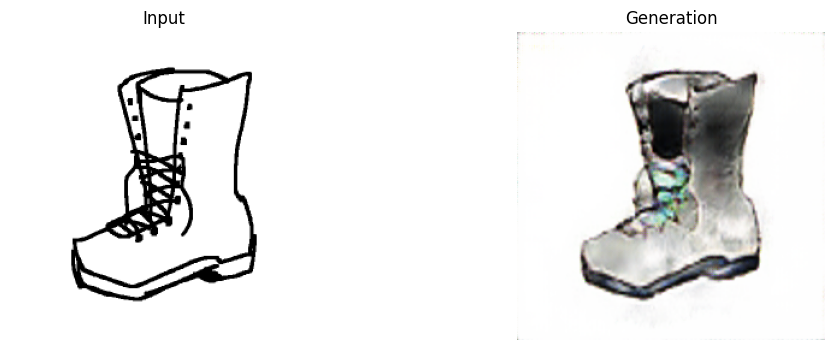

In [9]:
# Path setup
%cd /content/pytorch-CycleGAN-and-pix2pix

dataroot = '/content/pytorch-CycleGAN-and-pix2pix/datasets/my_custom_sketch'
test_dir = os.path.join(dataroot, 'test')
os.makedirs(test_dir, exist_ok=True)


# UI for user to draw sketch on canvas or upload image for generation
canvas_html = """
<div style="border: 1px solid #ccc; padding: 20px; width: 600px; text-align: center; background-color: #f9f9f9; margin: auto; border-radius: 10px; font-family: sans-serif;">
    <h3 style="color: black;">Sketch or Upload</h3>
    <canvas id="main_canvas" width="512" height="512"
        style="border:2px solid black; background:white; cursor:crosshair;"></canvas>

    <br><br>

    <button id="clear_btn">Clear</button>
    <button id="upload_btn">Upload</button>
    <input type="file" id="file_input" accept="image/*" style="display:none;">

    <br><br>

    <button id="done_btn" style="background:green;color:white;padding:10px 20px;">
        Generate
    </button>
</div>

<script>
let canvas = document.getElementById("main_canvas");
let ctx = canvas.getContext("2d");

ctx.fillStyle = "white";
ctx.fillRect(0,0,512,512);

ctx.strokeStyle = "black";
ctx.lineWidth = 6;   // thicker brush for larger canvas
ctx.lineCap = "round";

let drawing = false;

canvas.onmousedown = e => {
    drawing = true;
    ctx.beginPath();
    ctx.moveTo(e.offsetX, e.offsetY);
};

canvas.onmousemove = e => {
    if(drawing){
        ctx.lineTo(e.offsetX, e.offsetY);
        ctx.stroke();
    }
};

canvas.onmouseup = () => drawing = false;

document.getElementById("clear_btn").onclick = () => {
    ctx.fillRect(0,0,512,512);
};

let fileInput = document.getElementById("file_input");

document.getElementById("upload_btn").onclick = () => fileInput.click();

fileInput.onchange = e => {
    let reader = new FileReader();
    reader.onload = event => {
        let img = new Image();
        img.onload = () => {
            ctx.fillRect(0,0,512,512);
            ctx.drawImage(img, 0, 0, 512, 512);
        };
        img.src = event.target.result;
    };
    reader.readAsDataURL(e.target.files[0]);
};

var resolveData;
var data = new Promise(resolve => { resolveData = resolve; });

document.getElementById("done_btn").onclick = () => {
    resolveData(canvas.toDataURL("image/png"));
};
</script>
"""

def main():
    # Display canvas UI
    display(HTML(canvas_html))

    # Canvas output
    data_url = output.eval_js("data")

    try:
        result_path = '/content/pytorch-CycleGAN-and-pix2pix/results/edges2shoes_pretrained/test_latest/images/custom_input_A_fake.png'
        if os.path.exists(result_path):
            os.remove(result_path)

        # Decode base64 canvas image into OpenCV format
        header, encoded = data_url.split(",", 1)
        binary = base64.b64decode(encoded)
        img = cv2.imdecode(np.frombuffer(binary, np.uint8), cv2.IMREAD_COLOR)

        # Resize input to match Pix2Pix's training resolution (256x256)
        img_resized = cv2.resize(img, (256, 256))

        # Save input image in Pix2Pix's expected dataset structure
        input_path = os.path.join(test_dir, 'custom_input_A.png')
        cv2.imwrite(input_path, img_resized)

        print("Generating...It might take a few seconds to show the result.")

        # Run pretrained Pix2Pix model for sketch-to-image translation
        !python3 test.py \
            --dataroot {dataroot} \
            --name edges2shoes_pretrained \
            --model test \
            --netG unet_256 \
            --direction AtoB \
            --dataset_mode single \
            --norm batch \
            --num_test 1 > /dev/null 2>&1

        # Visualization
        if os.path.exists(result_path):
            plt.figure(figsize=(12,4))

            # Input
            plt.subplot(1,2,1)
            plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
            plt.title("Input")
            plt.axis('off')

            # Generation
            plt.subplot(1,2,2)
            plt.imshow(Image.open(result_path))
            plt.title("Generation")
            plt.axis('off')

            plt.show()

        else:
            print("No output generated.")

    except Exception as e:
        print("Error:", e)

# Run the pipeline
main()